Database is ready.

Dataset Preview:
                                         hadith_text  chapter
0         إنما الأعمال بالنيات وإنما لكل امرئ ما نوى  Worship
1  بني الإسلام على خمس شهادة أن لا إله إلا الله و...  Worship
2                                  الصلاة عماد الدين  Worship
3  من صام رمضان إيمانا واحتسابا غفر له ما تقدم من...  Worship
4                 أفضل الصلاة بعد الفريضة صلاة الليل  Worship

Class Distribution:
chapter
Worship         5
Ethics          5
Transactions    5
Family          5
Knowledge       5
Name: count, dtype: int64

Cleaned Text:
                                         hadith_text  \
0         إنما الأعمال بالنيات وإنما لكل امرئ ما نوى   
1  بني الإسلام على خمس شهادة أن لا إله إلا الله و...   
2                                  الصلاة عماد الدين   
3  من صام رمضان إيمانا واحتسابا غفر له ما تقدم من...   
4                 أفضل الصلاة بعد الفريضة صلاة الليل   

                                          clean_text  chapter  
0            انما الاعمال بالن

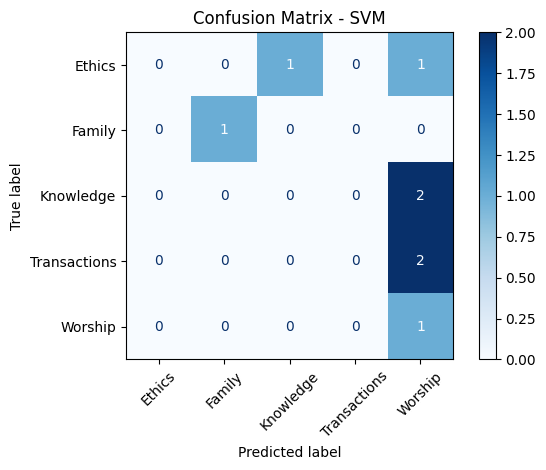


Training Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

      Ethics       0.00      0.00      0.00         2
      Family       0.20      1.00      0.33         1
   Knowledge       0.00      0.00      0.00         2
Transactions       0.00      0.00      0.00         2
     Worship       0.50      1.00      0.67         1

    accuracy                           0.25         8
   macro avg       0.14      0.40      0.20         8
weighted avg       0.09      0.25      0.12         8



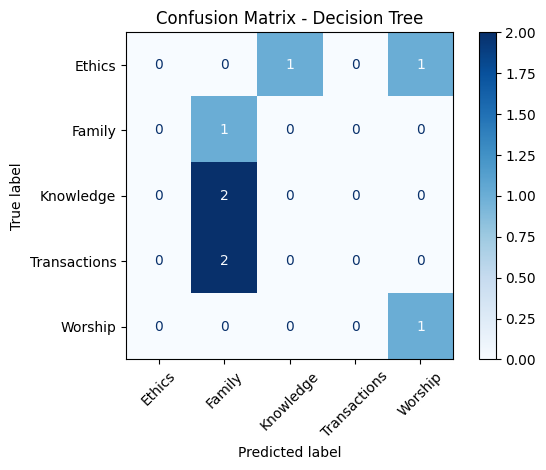


Training Model: Naive Bayes

Classification Report:
              precision    recall  f1-score   support

      Ethics       0.00      0.00      0.00         2
      Family       0.20      1.00      0.33         1
   Knowledge       0.00      0.00      0.00         2
Transactions       0.00      0.00      0.00         2
     Worship       0.50      1.00      0.67         1

    accuracy                           0.25         8
   macro avg       0.14      0.40      0.20         8
weighted avg       0.09      0.25      0.12         8



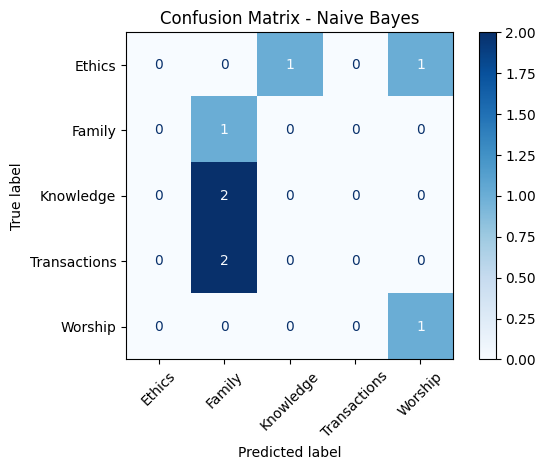


Training Model: KNN

Classification Report:
              precision    recall  f1-score   support

      Ethics       1.00      0.50      0.67         2
      Family       0.20      1.00      0.33         1
   Knowledge       0.00      0.00      0.00         2
Transactions       0.00      0.00      0.00         2
     Worship       1.00      1.00      1.00         1

    accuracy                           0.38         8
   macro avg       0.44      0.50      0.40         8
weighted avg       0.40      0.38      0.33         8



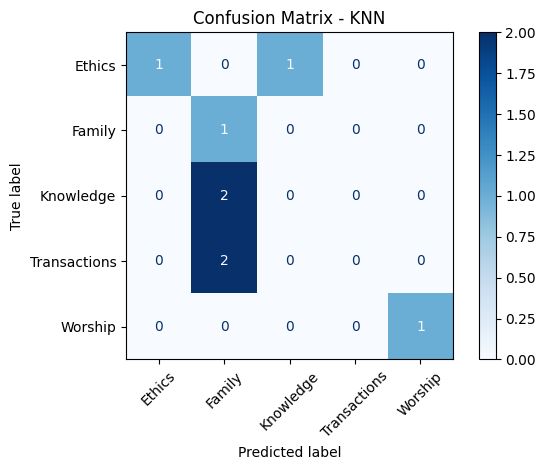


Final Model Comparison:
           Model  Accuracy  Precision  Recall  F1-score
0            SVM     0.250   0.145833   0.250  0.160714
1  Decision Tree     0.250   0.087500   0.250  0.125000
2    Naive Bayes     0.250   0.087500   0.250  0.125000
3            KNN     0.375   0.400000   0.375  0.333333

Best Model Based on F1-score:
Model             KNN
Accuracy        0.375
Precision         0.4
Recall          0.375
F1-score     0.333333
Name: 3, dtype: object

Error Analysis for SVM

Number of Wrong Predictions: 6
                                  Original Hadith  \
2                                من غشنا فليس منا   
3                           العلماء ورثة الأنبياء   
4                   إنما بعثت لأتمم مكارم الأخلاق   
5  إن الصدق يهدي إلى البر وإن البر يهدي إلى الجنة   
6                               بلغوا عني ولو آية   
7                                 لا ضرر ولا ضرار   

                                     Cleaned Text  True Chapter  \
2                                   

In [1]:
# ============================================================
# Al-Hadith Classification into 5 Chapters using ML Algorithms
# Algorithms: SVM, Decision Tree, Naive Bayes, KNN
# Features: TF-IDF
# Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix, Error Analysis
# ============================================================

import sqlite3
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier


# ============================================================
# 1. CREATE / CONNECT TO DATABASE
# ============================================================

db_name = "al_hadith_database.db"
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS hadith_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    hadith_text TEXT NOT NULL,
    chapter TEXT NOT NULL
)
""")

conn.commit()


# ============================================================
# 2. INSERT SAMPLE DATA
# Replace this section with your real Hadith database later.
# Chapters:
# 1. Worship
# 2. Ethics
# 3. Transactions
# 4. Family
# 5. Knowledge
# ============================================================

cursor.execute("SELECT COUNT(*) FROM hadith_data")
count = cursor.fetchone()[0]

if count == 0:
    sample_data = [
        # Worship
        ("إنما الأعمال بالنيات وإنما لكل امرئ ما نوى", "Worship"),
        ("بني الإسلام على خمس شهادة أن لا إله إلا الله وإقام الصلاة", "Worship"),
        ("الصلاة عماد الدين", "Worship"),
        ("من صام رمضان إيمانا واحتسابا غفر له ما تقدم من ذنبه", "Worship"),
        ("أفضل الصلاة بعد الفريضة صلاة الليل", "Worship"),

        # Ethics
        ("إن الصدق يهدي إلى البر وإن البر يهدي إلى الجنة", "Ethics"),
        ("ليس الشديد بالصرعة إنما الشديد الذي يملك نفسه عند الغضب", "Ethics"),
        ("من كان يؤمن بالله واليوم الآخر فليقل خيرا أو ليصمت", "Ethics"),
        ("تبسمك في وجه أخيك صدقة", "Ethics"),
        ("إنما بعثت لأتمم مكارم الأخلاق", "Ethics"),

        # Transactions
        ("التاجر الصدوق الأمين مع النبيين والصديقين والشهداء", "Transactions"),
        ("من غشنا فليس منا", "Transactions"),
        ("البيعان بالخيار ما لم يتفرقا", "Transactions"),
        ("رحم الله رجلا سمحا إذا باع وإذا اشترى", "Transactions"),
        ("لا ضرر ولا ضرار", "Transactions"),

        # Family
        ("خيركم خيركم لأهله وأنا خيركم لأهلي", "Family"),
        ("استوصوا بالنساء خيرا", "Family"),
        ("كلكم راع وكلكم مسؤول عن رعيته", "Family"),
        ("الرجل راع في أهل بيته ومسؤول عن رعيته", "Family"),
        ("من لا يرحم لا يرحم", "Family"),

        # Knowledge
        ("طلب العلم فريضة على كل مسلم", "Knowledge"),
        ("من سلك طريقا يلتمس فيه علما سهل الله له طريقا إلى الجنة", "Knowledge"),
        ("خيركم من تعلم القرآن وعلمه", "Knowledge"),
        ("العلماء ورثة الأنبياء", "Knowledge"),
        ("بلغوا عني ولو آية", "Knowledge"),
    ]

    cursor.executemany(
        "INSERT INTO hadith_data (hadith_text, chapter) VALUES (?, ?)",
        sample_data
    )

    conn.commit()

print("Database is ready.")


# ============================================================
# 3. LOAD DATA FROM DATABASE
# ============================================================

df = pd.read_sql_query("SELECT hadith_text, chapter FROM hadith_data", conn)

print("\nDataset Preview:")
print(df.head())

print("\nClass Distribution:")
print(df["chapter"].value_counts())


# ============================================================
# 4. ARABIC TEXT PREPROCESSING
# ============================================================

arabic_stopwords = [
    "من", "في", "على", "إلى", "عن", "أن", "إن", "كان", "ما",
    "لم", "لا", "قد", "كل", "هذا", "هذه", "هو", "هي", "ثم",
    "أو", "و", "يا", "إذا", "كما", "له", "لها", "به", "فيه"
]

def normalize_arabic(text):
    text = str(text)

    # Remove diacritics
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)

    # Normalize letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)

    # Remove non-Arabic characters
    text = re.sub(r"[^ء-ي\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in arabic_stopwords]

    return " ".join(words)


df["clean_text"] = df["hadith_text"].apply(normalize_arabic)

print("\nCleaned Text:")
print(df[["hadith_text", "clean_text", "chapter"]].head())


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X = df["clean_text"]
y = df["chapter"]

X_train, X_test, y_train, y_test, original_train, original_test = train_test_split(
    X,
    y,
    df["hadith_text"],
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ============================================================
# 6. DEFINE MODELS
# ============================================================

models = {
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=3)
}


# ============================================================
# 7. TRAIN, TEST, AND EVALUATE MODELS
# ============================================================

results = []

predictions_dict = {}

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print(f"Training Model: {model_name}")
    print("=" * 60)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000
        )),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    predictions_dict[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    labels = sorted(df["chapter"].unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\nFinal Model Comparison:")
print(results_df)

best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("\nBest Model Based on F1-score:")
print(best_model)


# ============================================================
# 9. ERROR ANALYSIS
# ============================================================

for model_name, y_pred in predictions_dict.items():

    print("\n" + "=" * 60)
    print(f"Error Analysis for {model_name}")
    print("=" * 60)

    error_df = pd.DataFrame({
        "Original Hadith": original_test.values,
        "Cleaned Text": X_test.values,
        "True Chapter": y_test.values,
        "Predicted Chapter": y_pred
    })

    wrong_predictions = error_df[
        error_df["True Chapter"] != error_df["Predicted Chapter"]
    ]

    print("\nNumber of Wrong Predictions:", len(wrong_predictions))

    if len(wrong_predictions) > 0:
        print(wrong_predictions)
    else:
        print("No classification errors.")

    file_name = f"error_analysis_{model_name.replace(' ', '_')}.csv"
    wrong_predictions.to_csv(file_name, index=False, encoding="utf-8-sig")
    print(f"Saved error analysis file: {file_name}")


# ============================================================
# 10. TEST NEW HADITH
# ============================================================

new_hadith = [
    "إن الصدق يهدي إلى البر",
    "خيركم خيركم لأهله",
    "من غشنا فليس منا",
    "طلب العلم فريضة على كل مسلم",
    "من صام رمضان إيمانا واحتسابا"
]

print("\n" + "=" * 60)
print("Prediction on New Hadith Examples")
print("=" * 60)

for model_name, model in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000
        )),
        ("classifier", model)
    ])

    pipeline.fit(X, y)

    cleaned_new_hadith = [normalize_arabic(text) for text in new_hadith]

    predictions = pipeline.predict(cleaned_new_hadith)

    print(f"\nModel: {model_name}")
    for text, pred in zip(new_hadith, predictions):
        print(f"Hadith: {text}")
        print(f"Predicted Chapter: {pred}")
        print("-" * 40)


# ============================================================
# 11. CLOSE DATABASE CONNECTION
# ============================================================

conn.close()